In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from scipy.io import wavfile
from scipy.fft import fft, ifft
from pydub import AudioSegment
import soundfile as sf

In [3]:
y, sr = librosa.load('C_Major_Piano.wav', sr=44100)

Text(0, 0.5, 'Amplitude')

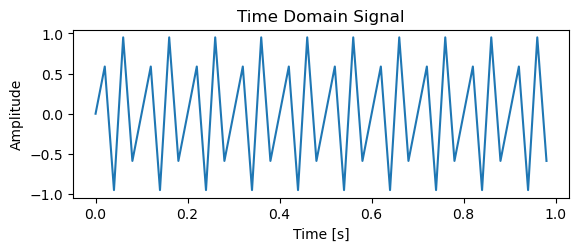

In [4]:
Fs = 50
T = 1/Fs 
t = np.arange(0, 1, T)  

f1 = 50
f2 = 120
signal = 0.7*np.sin(2*np.pi*f1*t) + 1.0*np.sin(2*np.pi*f2*t)

fft_values = np.fft.fft(signal)
N = len(signal)

freq_shift = 5

freq = np.fft.fftfreq(N, T)

X_shifted = np.zeros(N, dtype=complex)
for i in range(N):
    if i + freq_shift < N:
        X_shifted[i + freq_shift] = signal[i]

x_modified = np.fft.ifft(X_shifted)

magnitude = np.abs(fft_values)

plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title('Time Domain Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

/usr/lib64/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/lib64/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Amplitude')

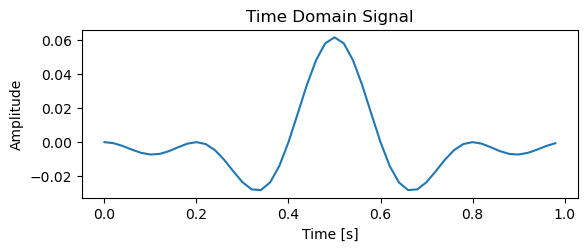

In [5]:
plt.subplot(2, 1, 1)
plt.plot(t, x_modified)
plt.title('Time Domain Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

Text(0, 0.5, 'Amplitude')

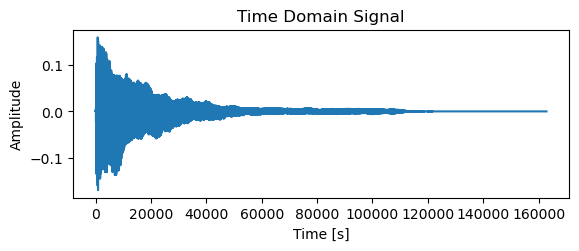

In [6]:
plt.subplot(2, 1, 1)
plt.plot(y)
plt.title('Time Domain Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

In [7]:
sample_rate, data = wavfile.read('/home/amk9809/Desktop/MyFolder/python_projects/PFE_2026/Synth/Projekat/C_Major_Piano.wav')

wavfile.write('Output_Note.wav', sample_rate, data.astype(np.int16))

In [8]:
def pitch_shift(audio, semitones):
    new_sample_rate = int(audio.frame_rate * (2.0 ** (semitones / 12.0)))
    return audio._spawn(audio.raw_data, overrides={'frame_rate': new_sample_rate}).set_frame_rate(audio.frame_rate)

audio = AudioSegment.from_file("/home/amk9809/Desktop/MyFolder/python_projects/PFE_2026/Synth/Projekat/C_Major_Piano.wav")
shifted_audio = pitch_shift(audio, 12)

shifted_audio.export("Output_Note.wav", format="wav")

<_io.BufferedRandom name='Output_Note.wav'>

In [ ]:
x, sr = sf.read("C_Major_Piano.wav")

if x.ndim > 1:
    x = x.mean(axis=1)

def pitch_shift(x, semitones):
    shift_by_semitones = 2 ** (semitones / 12)
    n = len(x)
    X = np.fft.rfft(x)
    k = np.arange(len(X))
    r_shift = k / shift_by_semitones

    real = np.interp(r_shift, k, X.real, left=0.0, right=0.0)
    imagine = np.interp(r_shift, k, X.imag, left=0.0, right=0.0)
    Y = real + 1j * imagine

    y = np.fft.irfft(Y, n=n)
    y = y / (np.max(np.abs(y)) + 1e-12) * 0.99
    return y

semitones = 12 ###Ovde se podesava koliko pitch-ujemo .wav

y = pitch_shift(x, semitones) 

sf.write("Output_Note.wav", y, sr)